# Урок 15.6. Правила дифференцирования: от степени до сигмоиды

**Интерактивная версия:** `lessons/lesson_15_6/web/index.html` — там те же опыты на живых графиках.

**После урока вы сможете:** выводить производные степени с любым показателем, экспоненты, логарифма и
синуса; дифференцировать суммы, произведения, частные и композиции (цепное правило «снаружи внутрь»);
пользоваться производной обратной функции, логарифмическим и неявным дифференцированием; проверять
стыки кусочных функций; выводить $\sigma' = \sigma(1 - \sigma)$, градиенты $g$ и вторые производные $h$ всех
потерь бустинга; проверять формулы численно, раскрывать $\frac00$ правилом Лопиталя и понимать прямой и
обратный режимы автоматического дифференцирования.

Блоки урока:

1. **Производные «атомов»:** константа и прямая, степень (квадрат, куб, бином), любой показатель, экспонента, логарифм, синус.
2. **Правила-операции:** линейность, произведение, частное, цепное правило, $f(ax + b)$.
3. **Приёмы:** обратная функция, логарифмическое и неявное дифференцирование, кусочные функции.
4. **В машинном обучении:** сигмоида и функции активации, градиенты и гессианы потерь, псевдо-остатки, своя функция потерь в XGBoost.
5. **Техника:** проверка числами, правило Лопиталя, автоматическое дифференцирование (дуальные числа и обратный проход).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math
from math import comb

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation
from matplotlib.patches import Rectangle

from gbcourse import datasets
from gbcourse.losses import get_loss
from gbcourse.plotting import use_course_style
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED, VIOLET

use_course_style()
plt.rcParams["animation.embed_limit"] = 30  # МБ: анимации встраиваются в ноутбук


def num_diff(f, x, eps=1e-5):
    """Центральная разность — численная производная."""
    return (f(x + eps) - f(x - eps)) / (2 * eps)


sig = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731

## Блок 1. Производные «атомов»

### 1. Константа, прямая и квадрат

$(c)' = 0$, $(kx + b)' = k$. Для квадрата: $(x + \Delta)^2 - x^2 = 2x\Delta + \Delta^2$ — две полоски и уголок;
уголок исчезает быстрее.

In [2]:
x = 3.0
print("  Δx    прирост     2xΔx      уголок Δx²   доля уголка")
for d in [1, 0.5, 0.1, 0.01]:
    growth = (x + d) ** 2 - x**2
    print(f"{d:5}  {growth:9.4f}  {2 * x * d:8.4f}  {d * d:10.4f}   {100 * d * d / growth:6.2f} %")
print("куб: 2.1³ − 8 =", round(2.1**3 - 8, 4), "= 3·4·0.1 + 3·2·0.01 + 0.001 =", round(1.2 + 0.06 + 0.001, 4))

  Δx    прирост     2xΔx      уголок Δx²   доля уголка
    1     7.0000    6.0000      1.0000    14.29 %
  0.5     3.2500    3.0000      0.2500     7.69 %
  0.1     0.6100    0.6000      0.0100     1.64 %
 0.01     0.0601    0.0600      0.0001     0.17 %
куб: 2.1³ − 8 = 1.261 = 3·4·0.1 + 3·2·0.01 + 0.001 = 1.261


Анимация: при $\Delta x \to 0$ доля уголка в приросте площади стремится к нулю.

In [3]:
fig, ax = plt.subplots(figsize=(4.4, 4.4), dpi=72)
deltas = np.linspace(1.0, 0.05, 30)


def frame(i):
    d = deltas[i]
    ax.clear()
    ax.add_patch(Rectangle((0, 0), x, x, color=BLUE, alpha=0.35))
    ax.add_patch(Rectangle((x, 0), d, x, color=ORANGE, alpha=0.6))
    ax.add_patch(Rectangle((0, x), x, d, color=ORANGE, alpha=0.6))
    ax.add_patch(Rectangle((x, x), d, d, color=RED, alpha=0.8))
    ax.set(xlim=(-0.2, 4.3), ylim=(-0.2, 4.3), aspect="equal", xticks=[], yticks=[])
    ax.set_title(f"Δx = {d:.2f}: уголок {100 * d * d / (2 * x * d + d * d):.1f} % прироста")
    return []


anim = animation.FuncAnimation(fig, frame, frames=len(deltas), interval=150)
plt.close(fig)
display(HTML(anim.to_jshtml()))

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


### 2. Натуральная степень: бином Ньютона

$\frac{(x + h)^n - x^n}{h} = n x^{n-1} + \binom n2 x^{n-2} h + \dots + h^{n-1}$ — все слагаемые, кроме главного,
содержат $h$ и исчезают при $h \to 0$.

In [4]:
n, x0 = 4, 1.0
for h in [0.5, 0.1, 0.01]:
    terms = [comb(n, k) * x0 ** (n - k) * h ** (k - 1) for k in range(1, n + 1)]
    print(f"h = {h:<5} слагаемые {np.round(terms, 6)}  сумма {sum(terms):.6f}  (главное {n * x0 ** (n - 1)})")
print("линейное приближение: 1.02¹⁰ ≈ 1 + 10·0.02 =", 1 + 10 * 0.02, "| точно", round(1.02**10, 4))
print("а здесь оно ломается: 1.01¹⁰⁰ ≈ 2, точно", round(1.01**100, 4))

h = 0.5   слагаемые [4.    3.    1.    0.125]  сумма 8.125000  (главное 4.0)
h = 0.1   слагаемые [4.e+00 6.e-01 4.e-02 1.e-03]  сумма 4.641000  (главное 4.0)
h = 0.01  слагаемые [4.e+00 6.e-02 4.e-04 1.e-06]  сумма 4.060401  (главное 4.0)
линейное приближение: 1.02¹⁰ ≈ 1 + 10·0.02 = 1.2 | точно 1.219
а здесь оно ломается: 1.01¹⁰⁰ ≈ 2, точно 2.7048


### 3. Любой показатель

$(x^a)' = a x^{a-1}$ для любого действительного $a$ при $x > 0$: корни и дроби переписываем степенями.

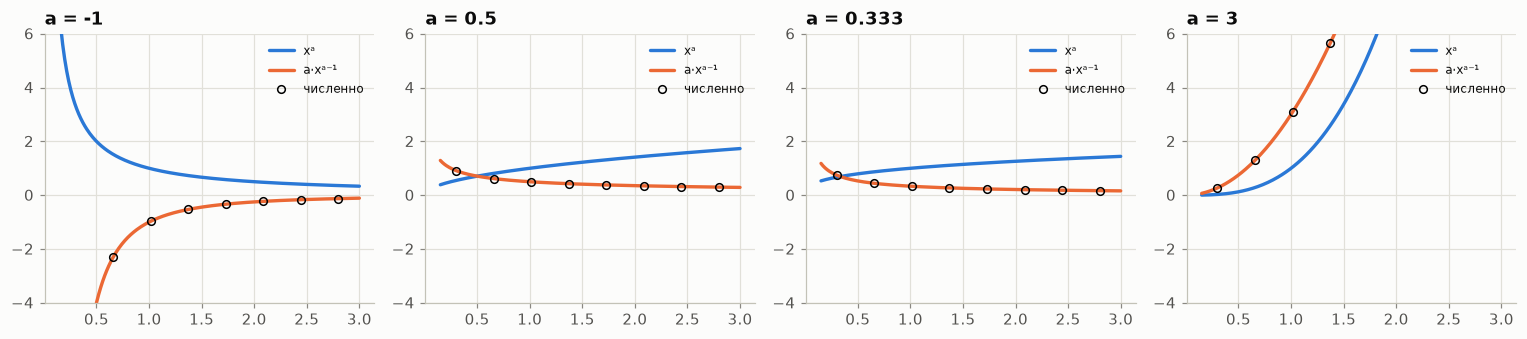

1/x²  при x = 4.0: формула -0.031250, численно -0.031250
√x    при x = 4.0: формула +0.250000, численно +0.250000
x√x   при x = 4.0: формула +3.000000, численно +3.000000
∛x    при x = 4.0: формула +0.132283, численно +0.132283


In [5]:
xs = np.linspace(0.15, 3, 300)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, a in zip(axes, [-1, 0.5, 1 / 3, 3]):
    f = lambda t, a=a: t**a  # noqa: E731
    ax.plot(xs, f(xs), color=BLUE, lw=2.2, label="xᵃ")
    ax.plot(xs, a * xs ** (a - 1), color=ORANGE, lw=2.2, label="a·xᵃ⁻¹")
    pts = np.linspace(0.3, 2.8, 8)
    ax.plot(pts, num_diff(f, pts), "o", mfc="none", color="k", ms=5, label="численно")
    ax.set(title=f"a = {a:.3g}", ylim=(-4, 6))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
for name, f, df, x in [("1/x²", lambda t: t**-2.0, lambda t: -2 * t**-3.0, 4.0), ("√x", np.sqrt, lambda t: 0.5 / np.sqrt(t), 4.0),
                       ("x√x", lambda t: t**1.5, lambda t: 1.5 * np.sqrt(t), 4.0), ("∛x", np.cbrt, lambda t: 1 / (3 * np.cbrt(t) ** 2), 4.0)]:
    print(f"{name:5} при x = {x}: формула {df(x):+.6f}, численно {num_diff(f, x):+.6f}")

### 4. Экспонента и логарифм

У $a^x$ отношение наклона к высоте постоянно и равно $\ln a$; при $a = e$ — единица. $(\ln x)' = 1/x$,
$(\log_a x)' = \frac{1}{x \ln a}$.

a = 2.0000: наклон / высота = 0.69315, ln a = 0.69315, время удвоения ln2/ln a = 1.0000
a = 3.0000: наклон / высота = 1.09861, ln a = 1.09861, время удвоения ln2/ln a = 0.6309
a = 2.7183: наклон / высота = 1.00000, ln a = 1.00000, время удвоения ln2/ln a = 0.6931
a = 10.0000: наклон / высота = 2.30259, ln a = 2.30259, время удвоения ln2/ln a = 0.3010


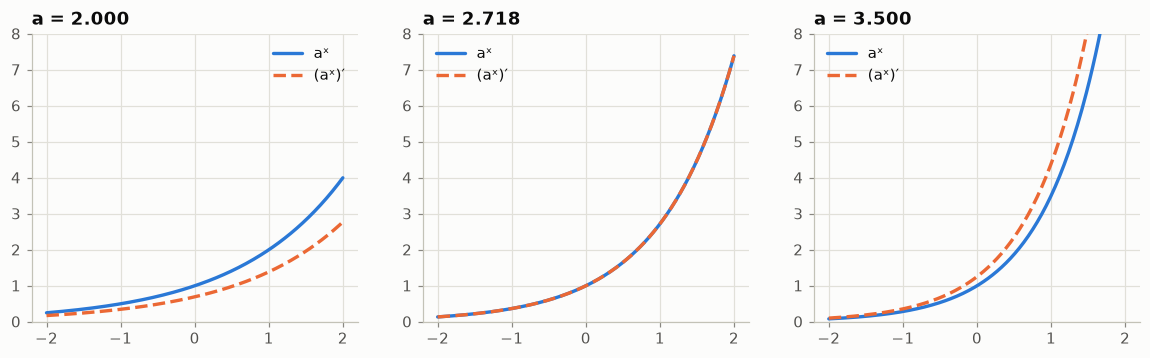

ln x    при x = 2: численно 0.500000, формула 0.500000
log₂ x  при x = 2: численно 0.721348, формула 0.721348
ln 5x   при x = 2: численно 0.500000, формула 0.500000


In [6]:
for a in [2, 3, np.e, 10]:
    ratio = num_diff(lambda t, a=a: a**t, 1.0) / a
    print(f"a = {a:.4f}: наклон / высота = {ratio:.5f}, ln a = {np.log(a):.5f}, время удвоения ln2/ln a = {np.log(2) / np.log(a):.4f}")

xs = np.linspace(-2, 2, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, a in zip(axes, [2, np.e, 3.5]):
    ax.plot(xs, a**xs, color=BLUE, lw=2.2, label="aˣ")
    ax.plot(xs, a**xs * np.log(a), "--", color=ORANGE, lw=2.2, label="(aˣ)′")
    ax.set(title=f"a = {a:.3f}", ylim=(0, 8))
    ax.legend()
plt.show()
for name, fn, d in [("ln x", np.log, lambda t: 1 / t), ("log₂ x", np.log2, lambda t: 1 / (t * np.log(2))),
                    ("ln 5x", lambda t: np.log(5 * t), lambda t: 1 / t)]:
    print(f"{name:7} при x = 2: численно {num_diff(fn, 2.0):.6f}, формула {d(2.0):.6f}")

### 5. Синус и косинус на окружности

Точка $(\cos t, \sin t)$ бежит по окружности со скоростью 1; её скорость $(-\sin t, \cos t)$ — касательная.
Вертикальная часть — $(\sin t)' = \cos t$, горизонтальная — $(\cos t)' = -\sin t$. Только в радианах.

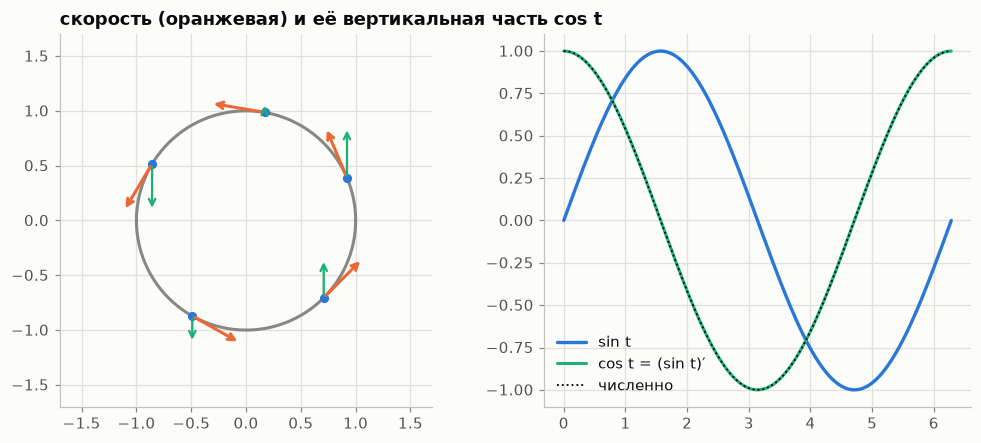

в градусах: d/dx sin(x°) = 0.015114994697529303 = π/180·cos = 0.015114994701951816


In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
ang = np.linspace(0, 2 * np.pi, 300)
a1.plot(np.cos(ang), np.sin(ang), color=MUTED)
for t in [0.4, 1.4, 2.6, 4.2, 5.5]:
    c, s = np.cos(t), np.sin(t)
    a1.plot(c, s, "o", color=BLUE)
    a1.annotate("", xy=(c - 0.5 * s, s + 0.5 * c), xytext=(c, s), arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2))
    a1.annotate("", xy=(c, s + 0.5 * c), xytext=(c, s), arrowprops=dict(arrowstyle="->", color=AQUA, lw=1.5))
a1.set(aspect="equal", xlim=(-1.7, 1.7), ylim=(-1.7, 1.7), title="скорость (оранжевая) и её вертикальная часть cos t")
ts = np.linspace(0, 2 * np.pi, 300)
a2.plot(ts, np.sin(ts), color=BLUE, lw=2.2, label="sin t")
a2.plot(ts, np.cos(ts), color=AQUA, lw=2, label="cos t = (sin t)′")
a2.plot(ts, num_diff(np.sin, ts), ":", color="k", lw=1.2, label="численно")
a2.legend()
plt.show()
deg = 30.0
print("в градусах: d/dx sin(x°) =", num_diff(lambda d: np.sin(np.radians(d)), deg), "= π/180·cos =", np.pi / 180 * np.cos(np.radians(deg)))

## Блок 2. Правила-операции

### 6. Линейность, произведение, частное

In [8]:
f = lambda t: 3 * t**2 - 5 * t + 7  # noqa: E731
print("(3x² − 5x + 7)' при x = 2:", num_diff(f, 2.0), "  формула 6x − 5 =", 6 * 2 - 5)
cases = [
    ("x·eˣ", lambda t: t * np.exp(t), lambda t: np.exp(t) * (1 + t), lambda t: np.exp(t)),
    ("x²·sin x", lambda t: t**2 * np.sin(t), lambda t: 2 * t * np.sin(t) + t**2 * np.cos(t), lambda t: 2 * t * np.cos(t)),
    ("x·ln x", lambda t: t * np.log(t), lambda t: np.log(t) + 1, lambda t: 1 / t),
    ("tg x", np.tan, lambda t: 1 / np.cos(t) ** 2, lambda t: np.cos(t) / -np.sin(t)),
    ("x/(1 + x²)", lambda t: t / (1 + t**2), lambda t: (1 - t**2) / (1 + t**2) ** 2, lambda t: 1 / (2 * t)),
]
x0 = 0.7
print(f"\nпри x = {x0}: функция   численно   правило   неверное «правило» (u′v′ или u′/v′)")
for name, fn, good, bad in cases:
    print(f"{name:11} {num_diff(fn, x0):9.5f} {good(x0):9.5f} {bad(x0):9.5f}")

(3x² − 5x + 7)' при x = 2: 7.0000000000902665   формула 6x − 5 = 7

при x = 0.7: функция   численно   правило   неверное «правило» (u′v′ или u′/v′)
x·eˣ          3.42338   3.42338   2.01375
x²·sin x      1.27668   1.27668   1.07078
x·ln x        0.64333   0.64333   1.42857
tg x          1.70945   1.70945  -1.18724
x/(1 + x²)    0.22972   0.22972   0.71429


Вклад каждого множителя в наклон произведения $x\,e^x$: «$u$ меняется, $v$ стоит» и наоборот.

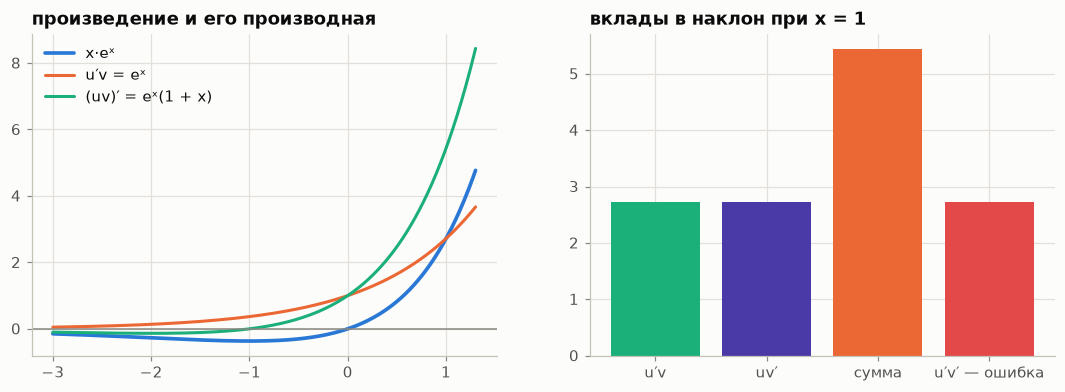

eᵖⁱ = 23.1407 > πᵉ = 22.4592 — потому что ln x / x убывает после x = e


In [9]:
xs = np.linspace(-3, 1.3, 300)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(xs, xs * np.exp(xs), color=BLUE, lw=2.4, label="x·eˣ")
a1.plot(xs, np.exp(xs), color=ORANGE, lw=2, label="u′v = eˣ")
a1.plot(xs, xs * np.exp(xs), ":", color=VIOLET, lw=0)
a1.plot(xs, xs * np.exp(xs) + np.exp(xs), color=AQUA, lw=2, label="(uv)′ = eˣ(1 + x)")
a1.axhline(0, color=MUTED, lw=1)
a1.legend()
a1.set(title="произведение и его производная")
parts = [np.e, np.e, 2 * np.e, np.e]
a2.bar(["u′v", "uv′", "сумма", "u′v′ — ошибка"], parts, color=[AQUA, VIOLET, ORANGE, RED])
a2.set(title="вклады в наклон при x = 1")
plt.show()
print("eᵖⁱ =", round(np.e**np.pi, 4), "> πᵉ =", round(np.pi**np.e, 4), "— потому что ln x / x убывает после x = e")

### 7. Цепное правило: усиления перемножаются

$\frac{dy}{dx} = \frac{dy}{dv}\cdot\frac{dv}{du}\cdot\frac{du}{dx}$ для $y = e^{\sin(x^2)}$. Сдвиг $\Delta x$ растягивается
каждым звеном в его производную раз.

In [10]:
links = [(lambda t: t**2, lambda t: 2 * t, "u = x²"), (np.sin, np.cos, "v = sin u"), (np.exp, np.exp, "y = eᵛ")]
x0 = 1.0
for dx in [0.2, 0.02, 0.002]:
    a, b = x0, x0 + dx
    gains = []
    for f, _, _ in links:
        fa, fb = f(a), f(b)
        gains.append((fb - fa) / (b - a))
        a, b = fa, fb
    print(f"Δx = {dx:<6} усиления звеньев {np.round(gains, 5)}  Δy/Δx = {(b - a) / dx:.5f}")
vals, exact = [x0], []
for f, df, _ in links:
    exact.append(df(vals[-1]))
    vals.append(f(vals[-1]))
print("точно:", np.round(exact, 5), " произведение", round(float(np.prod(exact)), 5), " = 2x·cos(x²)·e^{sin x²} =",
      round(2 * np.cos(1) * np.exp(np.sin(1)), 5))

Δx = 0.2    усиления звеньев [2.2     0.34088 2.50278]  Δy/Δx = 1.87693
Δx = 0.02   усиления звеньев [2.02    0.52316 2.34447]  Δy/Δx = 2.47759
Δx = 0.002  усиления звеньев [2.002   0.53862 2.32228]  Δy/Δx = 2.50414
точно: [2.      0.5403  2.31978]  произведение 2.50676  = 2x·cos(x²)·e^{sin x²} = 2.50676


Частный случай — внутри прямая: $\big(f(ax + b)\big)' = a\,f'(ax + b)$. Для нейрона $\sigma(wx + b)$ наибольший
наклон $w/4$ — в точке $x = -b/w$.

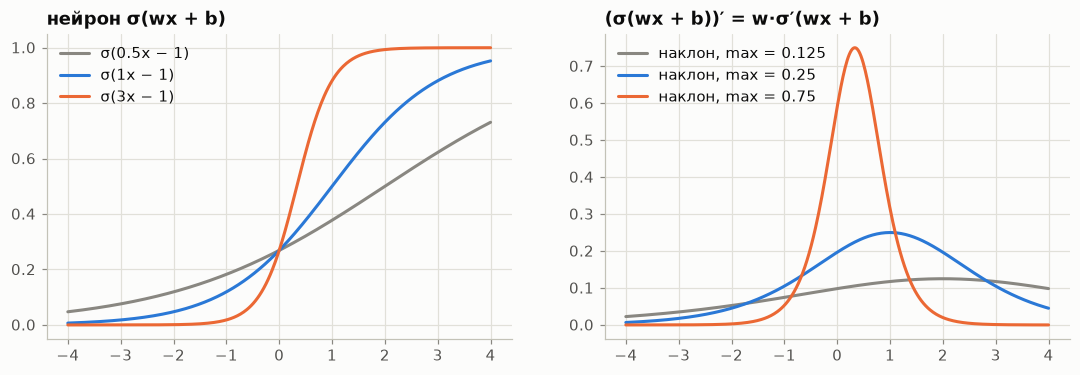

In [11]:
xs = np.linspace(-4, 4, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
for w, col in [(0.5, MUTED), (1, BLUE), (3, ORANGE)]:
    a1.plot(xs, sig(w * xs - 1), color=col, lw=2, label=f"σ({w}x − 1)")
    a2.plot(xs, w * sig(w * xs - 1) * (1 - sig(w * xs - 1)), color=col, lw=2, label=f"наклон, max = {w / 4:.3g}")
a1.legend()
a2.legend()
a1.set(title="нейрон σ(wx + b)")
a2.set(title="(σ(wx + b))′ = w·σ′(wx + b)")
plt.show()

## Блок 3. Приёмы

### 8. Обратная функция: $g' = 1 / f'(g)$

In [12]:
for name, f, df, x in [("arcsin", np.arcsin, lambda t: 1 / np.sqrt(1 - t**2), 0.6), ("arctg", np.arctan, lambda t: 1 / (1 + t**2), 2.0),
                       ("logit", lambda p: np.log(p / (1 - p)), lambda p: 1 / (p * (1 - p)), 0.9)]:
    print(f"{name:6} при x = {x}: формула {df(x):.6f}, численно {num_diff(f, x):.6f}")
print("наклон логита:", {p: round(1 / (p * (1 - p)), 1) for p in (0.5, 0.9, 0.99)})

arcsin при x = 0.6: формула 1.250000, численно 1.250000
arctg  при x = 2.0: формула 0.200000, численно 0.200000
logit  при x = 0.9: формула 11.111111, численно 11.111111
наклон логита: {0.5: 4.0, 0.9: 11.1, 0.99: 101.0}


### 9. Логарифмическое дифференцирование: $f' = f \cdot (\ln f)'$

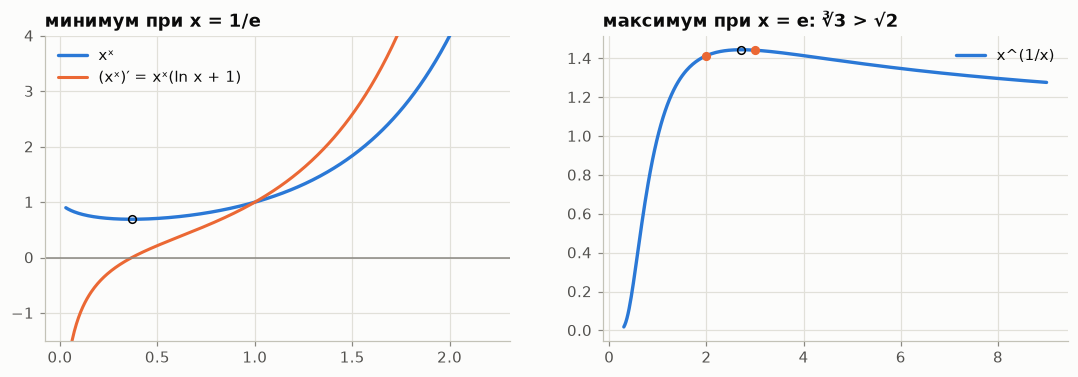

min xˣ: 0.36787944117144233 0.6922006275553464 | max x^(1/x): 2.718281828459045 1.444667861009766
(x(x+1)(x+2)(x+3))′ при x = 1: 49.99999999999999  численно 50.0


In [13]:
xs = np.linspace(0.03, 2.2, 400)
xs2 = np.linspace(0.3, 9, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.plot(xs, xs**xs, color=BLUE, lw=2.2, label="xˣ")
a1.plot(xs, xs**xs * (np.log(xs) + 1), color=ORANGE, lw=2, label="(xˣ)′ = xˣ(ln x + 1)")
a1.plot(1 / np.e, np.exp(-1 / np.e), "ko", mfc="none")
a1.axhline(0, color=MUTED, lw=1)
a1.set(ylim=(-1.5, 4), title="минимум при x = 1/e")
a1.legend()
a2.plot(xs2, xs2 ** (1 / xs2), color=BLUE, lw=2.2, label="x^(1/x)")
a2.plot(np.e, np.e ** (1 / np.e), "ko", mfc="none")
for k in (2, 3):
    a2.plot(k, k ** (1 / k), "o", color=ORANGE)
a2.set(title="максимум при x = e: ∛3 > √2")
a2.legend()
plt.show()
print("min xˣ:", 1 / np.e, np.exp(-1 / np.e), "| max x^(1/x):", np.e, np.e ** (1 / np.e))
f4 = lambda t: t * (t + 1) * (t + 2) * (t + 3)  # noqa: E731
print("(x(x+1)(x+2)(x+3))′ при x = 1:", f4(1.0) * (1 + 1 / 2 + 1 / 3 + 1 / 4), " численно", round(num_diff(f4, 1.0), 6))

### 10. Неявная функция: декартов лист $x^3 + y^3 = 6xy$

$3x^2 + 3y^2 y' = 6y + 6xy'$ ⇒ $y' = \frac{2y - x^2}{y^2 - 2x}$. Сверяем с параметрической производной
$\frac{dy}{dx} = \frac{y'(t)}{x'(t)}$ при $x = \frac{6t}{1 + t^3}$, $y = \frac{6t^2}{1 + t^3}$.

t = 0.4: точка (2.256, 0.902), неявно y′ = +0.88807, через параметр +0.88807
t = 1.0: точка (3.000, 3.000), неявно y′ = -1.00000, через параметр -1.00000
t = 1.8: точка (1.581, 2.845), неявно y′ = +0.64681, через параметр +0.64681
t = 3.0: точка (0.643, 1.929), неявно y′ = +1.41509, через параметр +1.41509


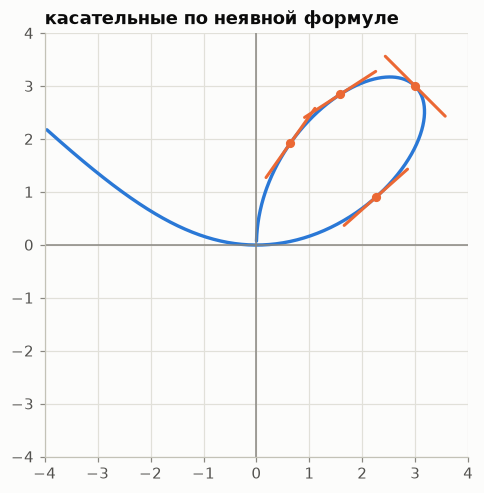

In [14]:
xt = lambda t: 6 * t / (1 + t**3)  # noqa: E731
yt = lambda t: 6 * t**2 / (1 + t**3)  # noqa: E731
tt = np.concatenate([np.linspace(-0.55, 6, 900), np.linspace(6, 80, 300)])
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot(xt(tt), yt(tt), color=BLUE, lw=2.2)
for t in [0.4, 1.0, 1.8, 3.0]:
    x0, y0 = xt(t), yt(t)
    k = (2 * y0 - x0**2) / (y0**2 - 2 * x0)
    kp = num_diff(yt, t) / num_diff(xt, t)
    u = np.linspace(-0.8, 0.8, 2) / np.sqrt(1 + k * k)
    ax.plot(x0 + u, y0 + k * u, color=ORANGE, lw=2)
    ax.plot(x0, y0, "o", color=ORANGE)
    print(f"t = {t}: точка ({x0:.3f}, {y0:.3f}), неявно y′ = {k:+.5f}, через параметр {kp:+.5f}")
ax.axhline(0, color=MUTED, lw=1)
ax.axvline(0, color=MUTED, lw=1)
ax.set(aspect="equal", xlim=(-4, 4), ylim=(-4, 4), title="касательные по неявной формуле")
plt.show()

### 11. Кусочные функции: стык Хьюбера гладкий, а вторая производная скачет

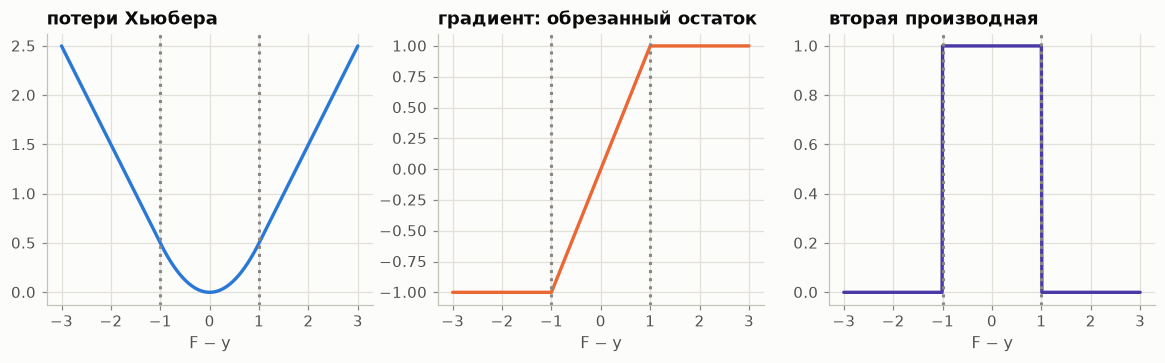

в стыке F − y = 1: f′ слева 0.999999949513608  справа 1.0000000005838672
|x| в нуле: слева -1.0  справа 1.0 — излом


In [15]:
r = np.linspace(-3, 3, 601)
delta = 1.0
L = np.where(np.abs(r) <= delta, 0.5 * r**2, delta * (np.abs(r) - 0.5 * delta))
g = np.clip(r, -delta, delta)
hh = (np.abs(r) <= delta).astype(float)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, v, title, col in zip(axes, [L, g, hh], ["потери Хьюбера", "градиент: обрезанный остаток", "вторая производная"], [BLUE, ORANGE, VIOLET]):
    ax.plot(r, v, color=col, lw=2.2)
    ax.axvline(delta, color=MUTED, ls=":")
    ax.axvline(-delta, color=MUTED, ls=":")
    ax.set(title=title, xlabel="F − y")
plt.show()
hub = lambda t: 0.5 * t**2 if abs(t) <= 1 else abs(t) - 0.5  # noqa: E731
e = 1e-7
print("в стыке F − y = 1: f′ слева", (hub(1) - hub(1 - e)) / e, " справа", (hub(1 + e) - hub(1)) / e)
print("|x| в нуле: слева", (abs(0) - abs(-e)) / e, " справа", (abs(e) - abs(0)) / e, "— излом")

## Блок 4. Производные в машинном обучении

### 12. Сигмоида и её родня

$\sigma' = \sigma(1 - \sigma)$ — площадь прямоугольника со сторонами $p$ и $1 - p$; максимум $\frac14$ в нуле.

z        : [-5.    -2.     0.     1.099  2.     5.   ]
σ(1 − σ) : [0.00665 0.10499 0.25    0.1875  0.10499 0.00665]
численно : [0.00665 0.10499 0.25    0.1875  0.10499 0.00665]
th′ = 1 − th²        верно: True
softplus′ = σ        верно: True
(ln σ)′ = 1 − σ      верно: True
(ln(1 − σ))′ = −σ    верно: True
затухание через 10 сигмоид: ≤ 0.25¹⁰ = 9.5367431640625e-07


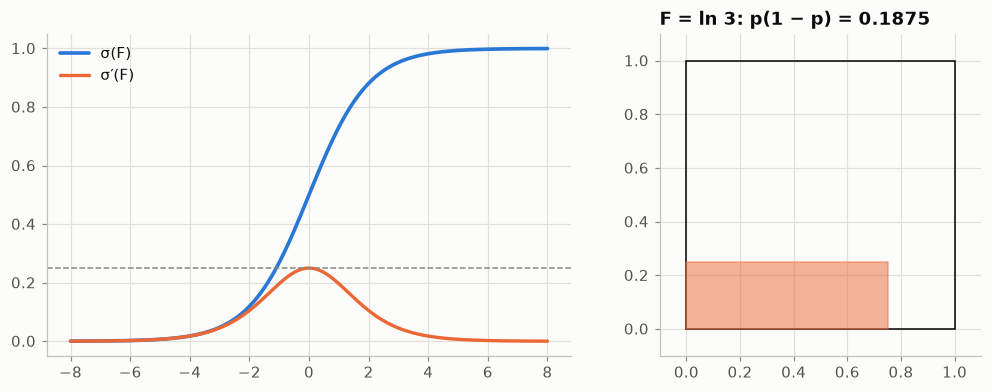

In [16]:
z = np.array([-5.0, -2.0, 0.0, np.log(3), 2.0, 5.0])
print("z        :", np.round(z, 3))
print("σ(1 − σ) :", np.round(sig(z) * (1 - sig(z)), 5))
print("численно :", np.round(num_diff(sig, z), 5))
family = {
    "th′ = 1 − th²": (np.tanh, lambda t: 1 - np.tanh(t) ** 2),
    "softplus′ = σ": (lambda t: np.log1p(np.exp(t)), sig),
    "(ln σ)′ = 1 − σ": (lambda t: np.log(sig(t)), lambda t: 1 - sig(t)),
    "(ln(1 − σ))′ = −σ": (lambda t: np.log(1 - sig(t)), lambda t: -sig(t)),
}
for name, (fn, d) in family.items():
    print(f"{name:20} верно: {np.allclose(num_diff(fn, z), d(z), atol=1e-8)}")
print("затухание через 10 сигмоид: ≤ 0.25¹⁰ =", 0.25**10)

zs = np.linspace(-8, 8, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
a1.plot(zs, sig(zs), color=BLUE, lw=2.4, label="σ(F)")
a1.plot(zs, sig(zs) * (1 - sig(zs)), color=ORANGE, lw=2.2, label="σ′(F)")
a1.axhline(0.25, color=MUTED, ls="--", lw=1)
a1.legend()
p = 0.75
a2.add_patch(Rectangle((0, 0), 1, 1, fill=False, ec="k"))
a2.add_patch(Rectangle((0, 0), p, 1 - p, color=ORANGE, alpha=0.5))
a2.set(aspect="equal", xlim=(-0.1, 1.1), ylim=(-0.1, 1.1), title=f"F = ln 3: p(1 − p) = {p * (1 - p):.4f}")
plt.show()

### 13. Градиенты и вторые производные всех потерь

| Потери | $g$ | $h$ |
|---|---|---|
| $\frac12(y - F)^2$ | $F - y$ | $1$ |
| $\lvert y - F\rvert$ | $\operatorname{sign}(F - y)$ | $0$ |
| Хьюбер | $\operatorname{clip}(F - y, \pm\delta)$ | $1$ или $0$ |
| квантильные | $-\alpha$ или $1 - \alpha$ | $0$ |
| log-loss | $\sigma(F) - y$ | $p(1 - p)$ |
| Пуассона | $e^F - y$ | $e^F$ |
| экспоненциальные | $-y e^{-yF}$ | $e^{-yF}$ |
| Гамма | $1 - y e^{-F}$ | $y e^{-F}$ |

Проверим каждую строку численно — и первую, и вторую производную.

L2          max|g − численно| = 1.5e-11   max|h − численно| = 4.4e-07
Хьюбер δ=1  max|g − численно| = 2.1e-12   max|h − численно| = 8.9e-08
log-loss    max|g − численно| = 1.6e-10   max|h − численно| = 1.4e-08
Пуассон     max|g − численно| = 1.8e-08   max|h − численно| = 1.4e-07
экспонента  max|g − численно| = 6.1e-09   max|h − численно| = 2.1e-08
Гамма       max|g − численно| = 1.2e-08   max|h − численно| = 6.8e-08


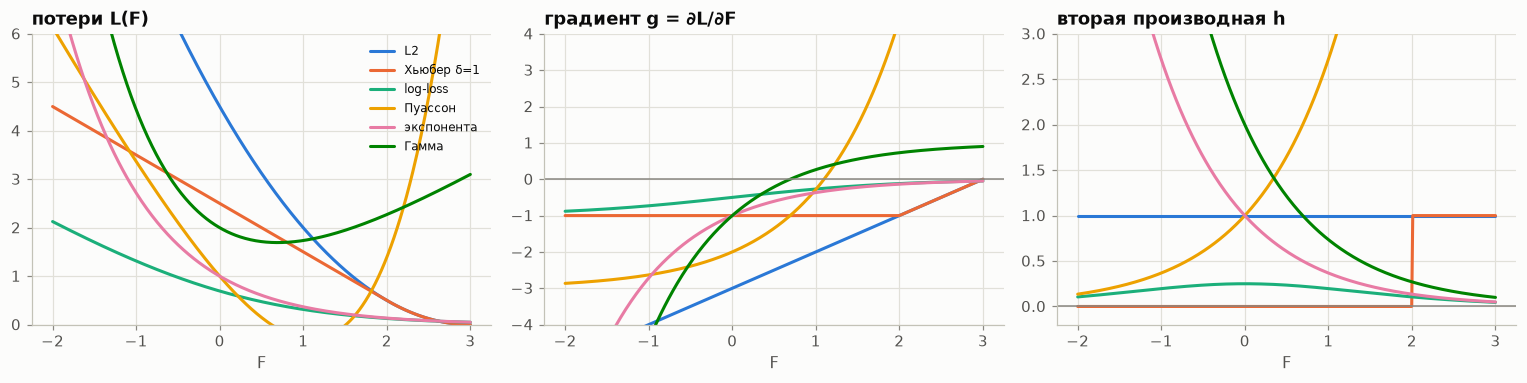

In [17]:
LOSSES = {
    "L2": (lambda F, y: 0.5 * (y - F) ** 2, lambda F, y: F - y, lambda F, y: np.ones_like(F), 3.0),
    "Хьюбер δ=1": (lambda F, y: np.where(np.abs(y - F) <= 1, 0.5 * (y - F) ** 2, np.abs(y - F) - 0.5), lambda F, y: np.clip(F - y, -1, 1),
                   lambda F, y: (np.abs(F - y) <= 1).astype(float), 3.0),
    "log-loss": (lambda F, y: np.log1p(np.exp(F)) - y * F, lambda F, y: sig(F) - y, lambda F, y: sig(F) * (1 - sig(F)), 1.0),
    "Пуассон": (lambda F, y: np.exp(F) - y * F, lambda F, y: np.exp(F) - y, lambda F, y: np.exp(F), 3.0),
    "экспонента": (lambda F, y: np.exp(-y * F), lambda F, y: -y * np.exp(-y * F), lambda F, y: y**2 * np.exp(-y * F), 1.0),
    "Гамма": (lambda F, y: y * np.exp(-F) + F, lambda F, y: 1 - y * np.exp(-F), lambda F, y: y * np.exp(-F), 2.0),
}
Fp = np.array([-1.3, -0.4, 0.7, 1.6, 2.4])  # без точек излома
e = 1e-4
for name, (Lf, gf, hf, y) in LOSSES.items():
    gn = (Lf(Fp + e, y) - Lf(Fp - e, y)) / (2 * e)
    hn = (Lf(Fp + e, y) - 2 * Lf(Fp, y) + Lf(Fp - e, y)) / e**2
    print(f"{name:11} max|g − численно| = {np.max(np.abs(gn - gf(Fp, y))):.1e}   max|h − численно| = {np.max(np.abs(hn - hf(Fp, y))):.1e}")

Fs = np.linspace(-2, 3, 400)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for name, (Lf, gf, hf, y) in LOSSES.items():
    axes[0].plot(Fs, Lf(Fs, y), lw=2, label=name)
    axes[1].plot(Fs, gf(Fs, y), lw=2, label=name)
    axes[2].plot(Fs, hf(Fs, y), lw=2, label=name)
axes[0].set(title="потери L(F)", ylim=(0, 6), xlabel="F")
axes[1].set(title="градиент g = ∂L/∂F", ylim=(-4, 4), xlabel="F")
axes[2].set(title="вторая производная h", ylim=(-0.2, 3), xlabel="F")
for ax in axes[1:]:
    ax.axhline(0, color=MUTED, lw=1)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Сверка с учебной библиотекой `gbcourse` и со scikit-learn.

In [18]:
_, y6 = datasets.toy_regression()
Fr = np.array([0.5, 4.8, 3.6, 6.1, 8.0, 12.4])
r6 = y6 - Fr
checks = {
    "squared": (get_loss("squared"), Fr - y6, np.ones(6)),
    "absolute": (get_loss("absolute"), np.sign(Fr - y6), np.zeros(6)),
    "huber": (get_loss("huber", delta=1.0), np.clip(Fr - y6, -1, 1), (np.abs(r6) <= 1) * 1.0),
    "quantile": (get_loss("quantile", alpha=0.9), np.where(y6 > Fr, -0.9, 0.1), np.zeros(6)),
}
for name, (loss, gm, hm) in checks.items():
    print(f"{name:9} gbcourse: g {np.allclose(loss.gradient(y6, Fr), gm)}, h {np.allclose(loss.hessian(y6, Fr), hm)}")
yb = np.array([1.0, 0.0, 1.0, 0.0])
Fb = np.array([2.0, 0.5, -1.0, -3.0])
print("logistic  gbcourse: g = p − y", np.allclose(get_loss("logistic").gradient(yb, Fb), sig(Fb) - yb),
      "| h = p(1 − p)", np.allclose(get_loss("logistic").hessian(yb, Fb), sig(Fb) * (1 - sig(Fb))))
yc, Fc = np.array([0.0, 3.0, 1.0]), np.array([0.0, 0.0, np.log(2)])
print("poisson   gbcourse: g = e^F − y", np.allclose(get_loss("poisson").gradient(yc, Fc), np.exp(Fc) - yc))
try:
    from sklearn._loss.loss import HalfBinomialLoss, HalfPoissonLoss, HalfSquaredError

    print("sklearn: L2", np.allclose(HalfSquaredError().gradient(y6, Fr), Fr - y6),
          "| log-loss", np.allclose(HalfBinomialLoss().gradient(yb, Fb), sig(Fb) - yb),
          "| Пуассон", np.allclose(HalfPoissonLoss().gradient(yc, Fc), np.exp(Fc) - yc))
except ImportError:
    print("scikit-learn не установлен — пропускаем")

squared   gbcourse: g True, h True
absolute  gbcourse: g True, h True
huber     gbcourse: g True, h True
quantile  gbcourse: g True, h True
logistic  gbcourse: g = p − y True | h = p(1 − p) True
poisson   gbcourse: g = e^F − y True


sklearn: L2 True | log-loss True | Пуассон True


### 14. Псевдо-остатки на шести квартирах и лучшая константа

Псевдо-остаток каждой квартиры — куда и с какой силой она тянет общий прогноз $c$. Градиентный спуск по $c$
сходится туда, где силы уравновешены: среднее, медиана, «между ними», 0.9-квантиль.

In [19]:
PB = {
    "MSE": lambda y, c: y - c,
    "MAE": lambda y, c: np.sign(y - c),
    "Хьюбер δ=2": lambda y, c: np.clip(y - c, -2, 2),
    "квантиль 0.9": lambda y, c: np.where(y > c, 0.9, -0.1),
}
for name, rf in PB.items():
    print(f"{name:13} при c = 6: −g = {np.round(rf(y6, 6.0), 2)}, среднее {rf(y6, 6.0).mean():+.3f}")
print()
for name, rf in PB.items():
    c = 3.0
    eta = 0.5 if name in ("MSE", "Хьюбер δ=2") else 0.2
    for _ in range(400):
        c = c + eta * rf(y6, c).mean()
    print(f"{name:13} спуск из c = 3 → c ≈ {c:.3f}")
print("\nклассификация: y = (1, 0, 1, 0), F = (2, 0.5, −1, −3) → y − p =", np.round(yb - sig(Fb), 3))

MSE           при c = 6: −g = [-4. -2. -3.  1.  3.  5.], среднее +0.000
MAE           при c = 6: −g = [-1. -1. -1.  1.  1.  1.], среднее +0.000
Хьюбер δ=2    при c = 6: −g = [-2. -2. -2.  1.  2.  2.], среднее -0.167
квантиль 0.9  при c = 6: −g = [-0.1 -0.1 -0.1  0.9  0.9  0.9], среднее +0.400

MSE           спуск из c = 3 → c ≈ 6.000
MAE           спуск из c = 3 → c ≈ 4.033
Хьюбер δ=2    спуск из c = 3 → c ≈ 5.500
квантиль 0.9  спуск из c = 3 → c ≈ 11.000

классификация: y = (1, 0, 1, 0), F = (2, 0.5, −1, −3) → y − p = [ 0.119 -0.622  0.731 -0.047]


MSE сходится к среднему 6, Хьюбер — к 5.5, квантильные — к 11 (с мелкими колебаниями шага). Спуск по MAE
останавливается, как только попадает на «полочку» медиан $[4, 7]$: там средний псевдо-остаток равен нулю —
любая точка полочки одинаково хороша.

### 15. Своя функция потерь в XGBoost: формулы урока в настоящей библиотеке

Передадим XGBoost градиент $g = p - y$ и вторую производную $h = p(1 - p)$, выведенные нами, и сравним со
встроенной `binary:logistic`. Для своей цели `base_score` — сырой логит (0), для встроенной — вероятность (0.5,
то есть тот же логит 0). Если формулы верны, прогнозы совпадут до точности float32.

In [20]:
Xc, yc2 = datasets.classification_2d("moons", n=300, noise=0.25, seed=3)
try:
    import xgboost as xgb

    dtrain = xgb.DMatrix(Xc, label=yc2)

    def stable_sig(m):
        """σ(m) без переполнения exp при больших |m|."""
        return 0.5 * (1 + np.tanh(m / 2))

    def logloss_obj(preds, dmat):
        y = dmat.get_label()
        p = stable_sig(preds)
        return p - y, p * (1 - p)  # g и h из шагов 19–20 урока

    common = {"max_depth": 3, "eta": 0.3, "tree_method": "exact", "seed": 0}
    own = xgb.train({**common, "base_score": 0.0}, dtrain, num_boost_round=30, obj=logloss_obj)
    builtin = xgb.train({**common, "objective": "binary:logistic", "base_score": 0.5}, dtrain, num_boost_round=30)
    m1 = own.predict(dtrain, output_margin=True)
    m2 = builtin.predict(dtrain, output_margin=True)
    print("макс. расхождение логитов своей и встроенной цели:", float(np.max(np.abs(m1 - m2))))

    def wrong_obj(preds, dmat):  # типичная ошибка: знак градиента
        y = dmat.get_label()
        p = stable_sig(preds)
        return y - p, p * (1 - p)

    bad = xgb.train({**common, "base_score": 0.0}, dtrain, num_boost_round=30, obj=wrong_obj)
    for name, booster in [("верный градиент p − y", own), ("ошибка: y − p", bad)]:
        m = booster.predict(dtrain, output_margin=True).astype(float)
        ll = float(np.mean(np.logaddexp(0, m) - yc2 * m))  # log-loss = ln(1 + e^F) − yF, устойчиво
        print(f"{name:22} log-loss на обучении = {ll:.4f}")
    print("с неверным знаком бустинг усердно УХУДШАЕТ модель: стартовый log-loss ln 2 =", round(math.log(2), 4))
except ImportError:
    print("xgboost не установлен — пропускаем")

макс. расхождение логитов своей и встроенной цели:

 1.430511474609375e-06
верный градиент p − y  log-loss на обучении = 0.0840
ошибка: y − p          log-loss на обучении = 93.7171
с неверным знаком бустинг усердно УХУДШАЕТ модель: стартовый log-loss ln 2 = 0.6931


## Блок 5. Техника и автоматизация

### 16. Проверка формул числами (gradient check)

In [21]:
def grad_check(f, df, xs, eps=1e-5):
    """Максимальное относительное расхождение формулы df с центральной разностью."""
    num = (f(xs + eps) - f(xs - eps)) / (2 * eps)
    return float(np.max(np.abs(num - df(xs)) / np.maximum(1, np.abs(num))))


xs = np.linspace(0.2, 2.0, 25)
tests = [
    ("sin(x²): 2x·cos(x²)", lambda t: np.sin(t**2), lambda t: 2 * t * np.cos(t**2)),
    ("sin(x²): cos(x²) — нет внутренней", lambda t: np.sin(t**2), lambda t: np.cos(t**2)),
    ("2ˣ: 2ˣ·ln 2", lambda t: 2.0**t, lambda t: 2.0**t * np.log(2)),
    ("2ˣ: x·2ˣ⁻¹ — правило степени", lambda t: 2.0**t, lambda t: t * 2.0 ** (t - 1)),
    ("xˣ: xˣ(ln x + 1)", lambda t: t**t, lambda t: t**t * (np.log(t) + 1)),
    ("σ: σ(1 − σ)", sig, lambda t: sig(t) * (1 - sig(t))),
    ("σ: 1 − σ — потерян квадрат", sig, lambda t: 1 - sig(t)),
]
for name, fn, d in tests:
    err = grad_check(fn, d, xs)
    print(f"{name:36} расхождение {err:.1e}  {'✓' if err < 1e-6 else '✗ ОШИБКА'}")

sin(x²): 2x·cos(x²)                  расхождение 3.8e-10  ✓
sin(x²): cos(x²) — нет внутренней    расхождение 7.5e-01  ✗ ОШИБКА
2ˣ: 2ˣ·ln 2                          расхождение 2.2e-11  ✓
2ˣ: x·2ˣ⁻¹ — правило степени         расхождение 6.8e-01  ✗ ОШИБКА
xˣ: xˣ(ln x + 1)                     расхождение 4.2e-10  ✓
σ: σ(1 − σ)                          расхождение 8.6e-12  ✓
σ: 1 − σ — потерян квадрат           расхождение 2.0e-01  ✗ ОШИБКА


### 17. Правило Лопиталя

Около точки, где $f(a) = g(a) = 0$, отношение $f/g$ стремится к $f'(a)/g'(a)$ (или, если и они нули, к $f''/g''$).

In [22]:
limits = [
    ("(x³ − 8)/(x − 2), x → 2", lambda x: (x**3 - 8) / (x - 2), 2, 12),
    ("sin x / x, x → 0", lambda x: np.sin(x) / x, 0, 1),
    ("(1 − cos x)/x², x → 0", lambda x: (1 - np.cos(x)) / x**2, 0, 0.5),
    ("(eˣ − 1 − x)/x², x → 0", lambda x: (np.expm1(x) - x) / x**2, 0, 0.5),
    ("x·ln x, x → 0⁺", lambda x: x * np.log(x), 0, 0),
    ("ln x / x, x → ∞", None, None, 0),
]
for name, q, a, lim in limits:
    if q is None:
        vals = [np.log(v) / v for v in (1e2, 1e4, 1e8)]
    else:
        vals = [q(a + h) for h in (0.1, 0.01, 0.001)]
    print(f"{name:26} {np.round(vals, 6)} → {lim}")
print("ловушка: (x² + 1)/(x + 1) при x → 0 =", (0.001**2 + 1) / 1.001, "≈ 1, а «Лопиталь» дал бы 2x/1 → 0")

(x³ − 8)/(x − 2), x → 2    [12.61     12.0601   12.006001] → 12
sin x / x, x → 0           [0.998334 0.999983 1.      ] → 1
(1 − cos x)/x², x → 0      [0.499583 0.499996 0.5     ] → 0.5
(eˣ − 1 − x)/x², x → 0     [0.517092 0.501671 0.500167] → 0.5
x·ln x, x → 0⁺             [-0.230259 -0.046052 -0.006908] → 0
ln x / x, x → ∞            [0.046052 0.000921 0.      ] → 0
ловушка: (x² + 1)/(x + 1) при x → 0 = 0.9990019980019981 ≈ 1, а «Лопиталь» дал бы 2x/1 → 0


### 18. Автоматическое дифференцирование

**Прямой режим** — дуальные числа: каждое число несёт свою производную, каждая операция обновляет её по
правилу урока. **Обратный режим** — граф вычислений: значения слева направо, градиенты справа налево.

In [23]:
class Dual:
    """Дуальное число a + bε, ε² = 0: значение и производная."""

    def __init__(self, v, d=0.0):
        self.v, self.d = v, d

    @staticmethod
    def wrap(o):
        return o if isinstance(o, Dual) else Dual(o)

    def __add__(self, o):
        o = Dual.wrap(o)
        return Dual(self.v + o.v, self.d + o.d)

    def __sub__(self, o):
        o = Dual.wrap(o)
        return Dual(self.v - o.v, self.d - o.d)

    def __mul__(self, o):
        o = Dual.wrap(o)
        return Dual(self.v * o.v, self.d * o.v + self.v * o.d)  # правило произведения

    def __truediv__(self, o):
        o = Dual.wrap(o)
        return Dual(self.v / o.v, (self.d * o.v - self.v * o.d) / o.v**2)  # правило частного

    def __pow__(self, k):
        return Dual(self.v**k, k * self.v ** (k - 1) * self.d)

    def __neg__(self):
        return Dual(-self.v, -self.d)

    __radd__ = __add__
    __rmul__ = __mul__

    def __rsub__(self, o):
        return Dual.wrap(o) - self

    def __rtruediv__(self, o):
        return Dual.wrap(o) / self


def dexp(a):
    return Dual(math.exp(a.v), math.exp(a.v) * a.d)  # цепное правило


def dsin(a):
    return Dual(math.sin(a.v), math.cos(a.v) * a.d)


def dlog(a):
    return Dual(math.log(a.v), a.d / a.v)


xd = Dual(1.0, 1.0)
print("(x·eˣ)′ при 1:", (xd * dexp(xd)).d, " точно:", 2 * math.e)
print("(e^{sin x²})′ при 1:", dexp(dsin(xd * xd)).d, " точно:", 2 * math.cos(1) * math.exp(math.sin(1)))
s = 1 / (1 + dexp(-xd))
print("σ′(1) через частное:", s.d, " σ(1 − σ):", s.v * (1 - s.v))
print("(xˣ)′ = (e^{x ln x})′ при 2:", dexp(Dual(2.0, 1.0) * dlog(Dual(2.0, 1.0))).d, " точно:", 4 * (math.log(2) + 1))

(x·eˣ)′ при 1: 5.43656365691809  точно: 5.43656365691809
(e^{sin x²})′ при 1: 2.506761534986894  точно: 2.506761534986894
σ′(1) через частное: 0.19661193324148188  σ(1 − σ): 0.19661193324148185
(xˣ)′ = (e^{x ln x})′ при 2: 6.772588722239782  точно: 6.772588722239782


In [24]:
class Node:
    """Узел графа вычислений для обратного режима."""

    def __init__(self, v, parents=()):
        self.v, self.g, self.parents = v, 0.0, parents

    @staticmethod
    def wrap(o):
        return o if isinstance(o, Node) else Node(o)

    def __add__(self, o):
        o = Node.wrap(o)
        return Node(self.v + o.v, [(self, 1.0), (o, 1.0)])

    def __mul__(self, o):
        o = Node.wrap(o)
        return Node(self.v * o.v, [(self, o.v), (o, self.v)])

    __radd__ = __add__
    __rmul__ = __mul__

    def __neg__(self):
        return self * -1.0

    def __rsub__(self, o):
        return Node.wrap(o) + (-self)


def nsig(a):
    sv = 1 / (1 + math.exp(-a.v))
    return Node(sv, [(a, sv * (1 - sv))])


def nlog(a):
    return Node(math.log(a.v), [(a, 1 / a.v)])


def backward(out):
    order, seen = [], set()

    def visit(n):
        if id(n) not in seen:
            seen.add(id(n))
            for par, _ in n.parents:
                visit(par)
            order.append(n)

    visit(out)
    out.g = 1.0
    for n in reversed(order):
        for par, local in n.parents:
            par.g += n.g * local  # градиент узла = градиент следующего × локальная производная


Xl, Yl = Xc[:40, 0], yc2[:40]
w, b = Node(1.5), Node(-0.5)
L = Node(0.0)
for xi, yi in zip(Xl, Yl):
    pn = nsig(w * float(xi) + b)
    L = L + (-(float(yi) * nlog(pn) + (1 - float(yi)) * nlog(1 - pn)))
backward(L)
pv = sig(1.5 * Xl - 0.5)
print("обратный проход: ∂L/∂w =", round(w.g, 8), " ∂L/∂b =", round(b.g, 8))
print("формула        : Σ(p − y)x =", round(float(np.sum((pv - Yl) * Xl)), 8), " Σ(p − y) =", round(float(np.sum(pv - Yl)), 8))

обратный проход: ∂L/∂w = 1.3110232  ∂L/∂b = 2.26838185
формула        : Σ(p − y)x = 1.3110232  Σ(p − y) = 2.26838185


**Сколько стоит градиент.** У модели с $n$ параметрами прямой режим требует $n$ проходов (по проходу на
параметр), численный — $2n$ вычислений функции, обратный — один прямой и один обратный проход независимо
от $n$. Поэтому нейросети учат обратным распространением, а для проверки формул хватает численной производной.

## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ Производные многочлена и $x^2 e^{-x}$; нули производной.
2. ★☆☆ Перепишите степенями и продифференцируйте $\frac{3}{x^2} + \sqrt[3]{x} - \frac{1}{\sqrt x}$.
3. ★★☆ Выведите $(\operatorname{tg} x)'$ правилом частного и проверьте численно.
4. ★★☆ Цепочки: $(3x + 1)^5$, $\sqrt{1 + x^2}$, $e^{\sin(x^2)}$, $\ln\sigma(F)$.
5. ★★☆ Логарифмическое дифференцирование $x^x$ и $x^{1/x}$; экстремумы.
6. ★★☆ Касательная к эллипсу неявным дифференцированием.
7. ★★☆ Градиент и вторая производная потерь Хьюбера.
8. ★★★ Квантильные потери: градиент и лучшая константа для α = 0.9 на шести квартирах.
9. ★★★ Потери Пуассона: $g$, $h$, шаги Ньютона до $|g| < 10^{-6}$.
10. ★★★ Деление и логарифм в классе `Dual`; σ′(0) и $(x^x)'$.
11. ★★★ Своя функция потерь для XGBoost: градиент и гессиан потерь Пуассона против `count:poisson`.